# mCH vs gene expression correlation (Fig 3I, S23B)

For the major types with matched pseudobulk RNA, we correlate **gene-body mCH** with
**gene expression** across subtypes. **Fig 3I** shows, per major type, the distribution of
that correlation across genes (one violin per major type). **Fig S23B** shows how the
correlation-across-genes depends on **distance to the TSS** (per-subtype dots at ±1–10 kb
flanks plus the gene body).

Source: `analysis/mCH_geneexpr/{L1}/step3.mCH_geneexpr.ipynb` (one notebook per major type).
Here we load the per-type correlation arrays those notebooks write and assemble the two
published panels (the cross-major-type violin assembly was done ad hoc and is reconstructed here).

## 📥 Required input files

- `{ENTEX_ROOT}/L1color.tsv` · _major-type color/annotation_
- `{ENTEX_ROOT}/analysis/mCH_geneexpr/{L1}/corr_cross_ct_genebody.npy` · _per-gene mCH↔expr corr across subtypes (Fig 3I)_
- `{ENTEX_ROOT}/analysis/mCH_geneexpr/{L1}/corr_cross_gene.npy`, `corr_cross_gene_genebody.npy` · _corr across genes at each TSS-flank distance (Fig S23B)_

The per-type arrays are produced upstream in `mCH_geneexpr/{L1}/step3.mCH_geneexpr.ipynb`
from `subtype_geneCH.hdf` (gene-body mCH), `bulkexpr_*.hdf` (pseudobulk RNA), and the
subtype `allc` TSS-flank profiles.

In [1]:
# === Reproduction setup — edit ENTEX_ROOT / REF_ROOT for your machine ===
import os, sys
ENTEX_ROOT = os.environ.get('ENTEX_ROOT', '/large_storage/zhoulab/zhoujt/project/ENTEx')
REF_ROOT   = os.environ.get('REF_ROOT',   '/large_storage/zhoulab/ref')
BOOK_ROOT  = os.environ.get('BOOK_ROOT',  f'{ENTEX_ROOT}/analysis/HumanCellEpigenomeAtlas')
sys.path.insert(0, BOOK_ROOT)
os.chdir(f'{ENTEX_ROOT}/analysis')
import repro_guard

In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib as mpl
import matplotlib.pyplot as plt
mpl.style.use('default')
mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype'] = 42
mpl.rcParams['font.family'] = 'sans-serif'
mpl.rcParams['font.sans-serif'] = 'Helvetica'

geneexpr_dir = f'{ENTEX_ROOT}/analysis/mCH_geneexpr/'
L1_meta = pd.read_csv(f'{ENTEX_ROOT}/L1color.tsv', sep='\t', header=0, index_col=0)
# major types with matched RNA + the mCH-expr correlation analysis
ct_list = ['c0', 'c5', 'c10', 'c13', 'c16', 'c27']

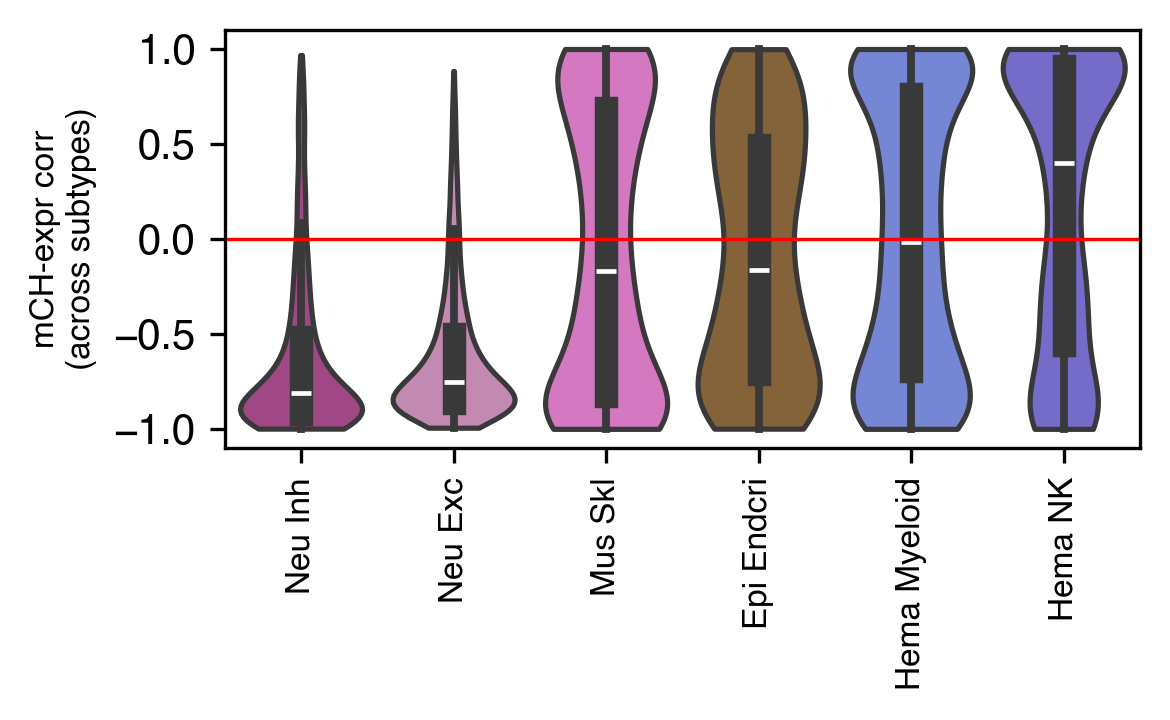

In [3]:
# Fig 3I — one violin per major type (distribution across genes of the gene-body
# mCH-vs-expression correlation across subtypes), sorted by median.
corr_by_l1 = {}
for ct in ct_list:
    f = f'{geneexpr_dir}{ct}/corr_cross_ct_genebody.npy'
    if os.path.exists(f):
        corr_by_l1[ct] = np.load(f)

order = sorted(corr_by_l1, key=lambda k: np.median(corr_by_l1[k]))
fig, ax = plt.subplots(figsize=(4, 2.5), dpi=300)
sns.violinplot(data=[corr_by_l1[k] for k in order], ax=ax,
               palette=[L1_meta.loc[k, 'color'] for k in order], cut=0, inner='box')
ax.axhline(0, color='r', lw=0.8)
ax.set_xticks(np.arange(len(order)))
ax.set_xticklabels(L1_meta.loc[order, 'L1_abbr'], rotation=90, fontsize=8)
ax.set_ylabel('mCH-expr corr\n(across subtypes)', fontsize=8)
fig.tight_layout()
fig.savefig('mCH_geneexpr/mCH_expr_corr_across_subtypes_violin.pdf', transparent=True)  # Fig 3I

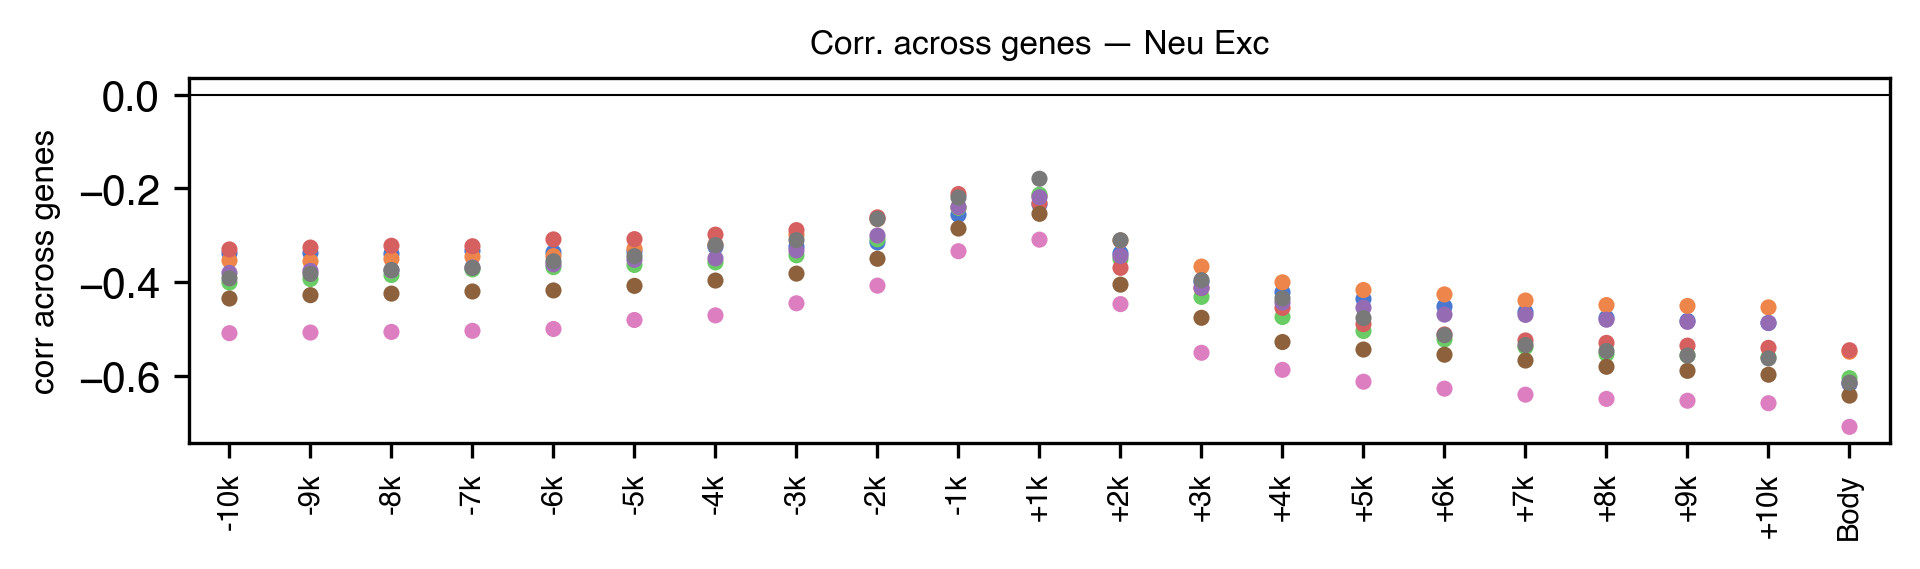

In [4]:
# Fig S23B — correlation across genes vs distance to TSS, per subtype, for a
# representative major type (Neu Exc = c10, the clearest signal / most subtypes).
rep = 'c10'
cross_gene = np.load(f'{geneexpr_dir}{rep}/corr_cross_gene.npy')            # (20 dist bins, n_subtype)
cross_gene_gb = np.load(f'{geneexpr_dir}{rep}/corr_cross_gene_genebody.npy')  # (n_subtype,)
cross_gene = np.concatenate([cross_gene, cross_gene_gb[None, :]], axis=0)     # +body -> (21, n_subtype)
n_sub = cross_gene.shape[1]
palette = sns.color_palette('muted', n_sub)

fig, ax = plt.subplots(figsize=(6.5, 2), dpi=300)
ax.scatter(np.repeat(np.arange(21), n_sub), cross_gene.flatten(),
           c=np.tile(palette, (21, 1)), s=15, edgecolor='none', rasterized=True)
ax.axhline(0, color='k', lw=0.5)
ax.set_title(f'Corr. across genes — {L1_meta.loc[rep, "L1_abbr"]}', fontsize=8)
ax.set_xticks(np.arange(21))
ticklabels = [f'-{x}k' for x in np.arange(1, 11)][::-1] + [f'+{x}k' for x in np.arange(1, 11)] + ['Body']
ax.set_xticklabels(ticklabels, rotation=90, fontsize=7)
ax.set_xlim([-0.5, 20.5])
ax.set_ylabel('corr across genes', fontsize=8)
fig.tight_layout()
fig.savefig('mCH_geneexpr/mCH_expr_corr_across_genes_TSS.pdf', transparent=True)  # Fig S23B